In [1]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter

BASE = Path(r"C:\Projects\RoadGuard-AI\data\raw")
CLASSES = ["D00", "D10", "D20", "D40"]
COLORS  = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12"]

## Count class's Element 

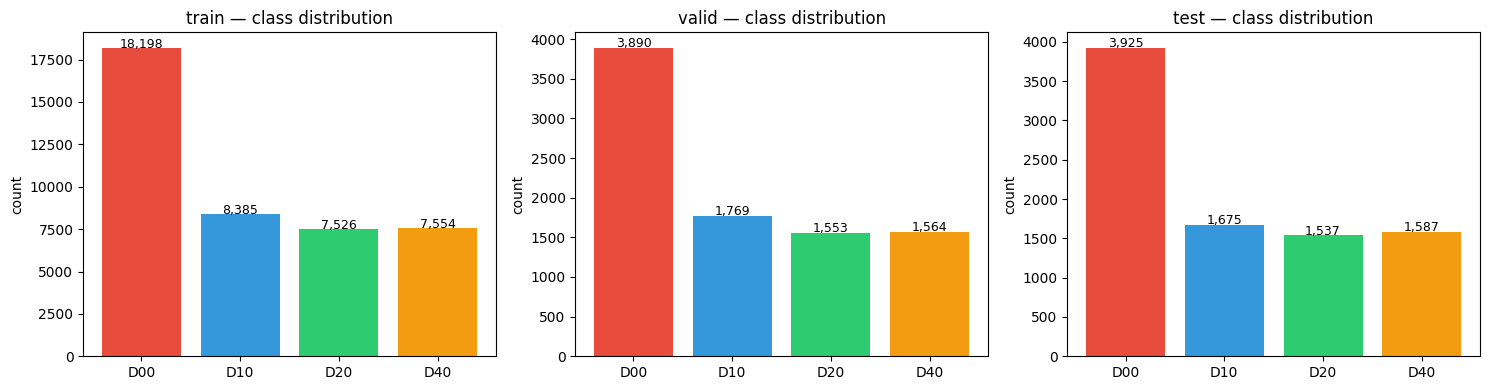

In [2]:
def count_classes(split):
    labels_dir = BASE / split / "labels"
    counter = Counter()
    for f in labels_dir.glob("*.txt"):
        for line in f.read_text().strip().splitlines():
            if line:
                cls = int(line.split()[0])
                counter[cls] += 1
    return counter

splits = ["train", "valid", "test"]
counts = {s: count_classes(s) for s in splits}

# رسم التوزيع
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, splits):
    vals = [counts[split].get(i, 0) for i in range(4)]
    bars = ax.bar(CLASSES, vals, color=COLORS)
    ax.set_title(f"{split} — class distribution")
    ax.set_ylabel("count")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Projects\RoadGuard-AI\results\visualizations\class_distribution.png", dpi=150)
plt.show()

In [3]:
counts

{'train': Counter({0: 18198, 1: 8385, 3: 7554, 2: 7526, 4: 4628}),
 'valid': Counter({0: 3890, 1: 1769, 3: 1564, 2: 1553, 4: 965}),
 'test': Counter({0: 3925, 1: 1675, 3: 1587, 2: 1537, 4: 951})}

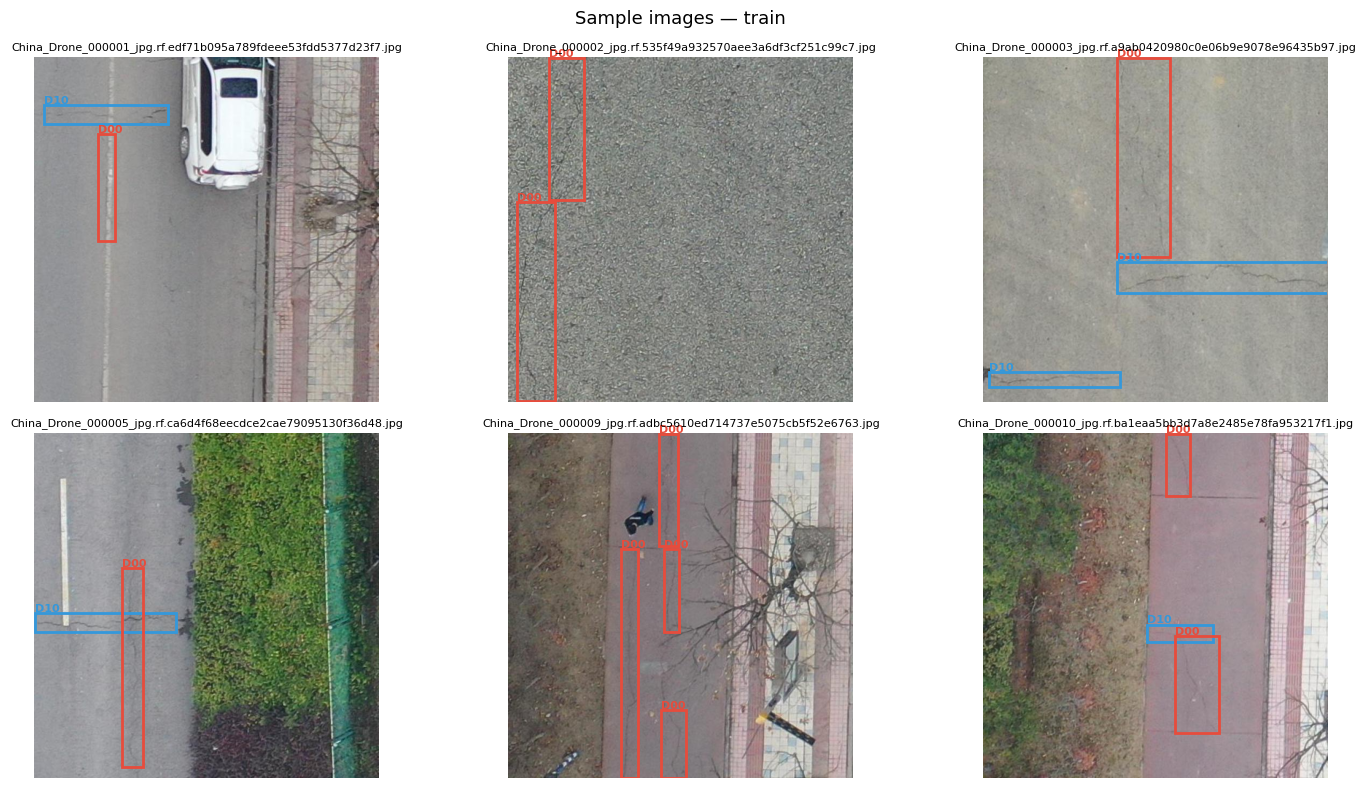

In [5]:
def show_samples(split, n=6):
    img_dir = BASE / split / "images"
    lbl_dir = BASE / split / "labels"
    imgs = list(img_dir.glob("*.jpg"))[:n]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, img_path in zip(axes, imgs):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        ax.imshow(img)

        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                if not line: continue
                cls, cx, cy, bw, bh = map(float, line.split())
                cls = int(cls)
                x = (cx - bw/2) * w
                y = (cy - bh/2) * h
                rect = patches.Rectangle(
                    (x, y), bw*w, bh*h,
                    linewidth=2,
                    edgecolor=COLORS[cls],
                    facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x, y-4, CLASSES[cls],
                        color=COLORS[cls],
                        fontsize=8, fontweight="bold")

        ax.axis("off")
        ax.set_title(img_path.name, fontsize=8)

    plt.suptitle(f"Sample images — {split}", fontsize=13)
    plt.tight_layout()
    plt.savefig(rf"C:\Projects\RoadGuard-AI\results\visualizations\samples_{split}.png", dpi=150)
    plt.show()

show_samples("train")

In [4]:
from pathlib import Path

BASE = Path(r"C:\Projects\RoadGuard-AI\data\raw")
labels_dir = BASE / "train" / "labels"

# دوّر على ملف فيه class 4
for f in labels_dir.glob("*.txt"):
    for line in f.read_text().strip().splitlines():
        if line and int(line.split()[0]) == 4:
            print(f"الملف: {f.name}")
            print(f"السطر: {line}")
            break
    else:
        continue
    break

الملف: China_Drone_000048_jpg.rf.8ea4f62b43d2293939b3152aaf9789b9.txt
السطر: 4 0.4890625 0.35625 0.134375 0.38125


تم تحميل الصورة بنجاح: C:\Projects\RoadGuard-AI\data\raw\train\images\China_Drone_000048_jpg.rf.8ea4f62b43d2293939b3152aaf9789b9.jpg
تم العثور على ملف التسمية: C:\Projects\RoadGuard-AI\data\raw\train\labels\China_Drone_000048_jpg.rf.8ea4f62b43d2293939b3152aaf9789b9.txt
السطر: 4 0.4890625 0.35625 0.134375 0.38125


IndexError: list index out of range

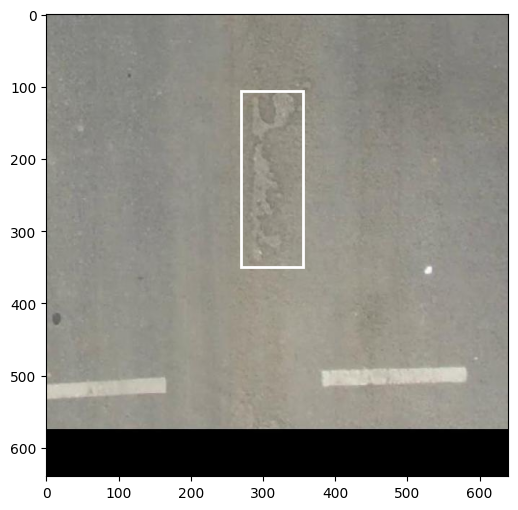

In [ ]:
img_path = BASE / "train" / "images" / ("China_Drone_000048_jpg.rf.8ea4f62b43d2293939b3152aaf9789b9" + ".jpg")
img = cv2.imread(str(img_path))
if img is None:
    print(f"فشل في تحميل الصورة: {img_path}")
else:
    print(f"تم تحميل الصورة بنجاح: {img_path}")
    h, w = img.shape[:2]
    lbl_path = BASE / "train" / "labels" / (img_path.stem + ".txt")
    if lbl_path.exists():
        print(f"تم العثور على ملف التسمية: {lbl_path}")
        for line in lbl_path.read_text().strip().splitlines():
            print(f"السطر: {line}")
    else:
        print(f"لم يتم العثور على ملف التسمية: {lbl_path}")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

ax.imshow(img)

for line in lbl_path.read_text().strip().splitlines():
    if not line: continue
    cls, cx, cy, bw, bh = map(float, line.split())
    cls = int(cls)
    x = (cx - bw/2) * w
    y = (cy - bh/2) * h
    color = COLORS[cls] if cls < len(COLORS) else "#FFFFFF"
    rect = patches.Rectangle(
        (x, y), bw*w, bh*h,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)
    label = CLASSES[cls] if cls < len(CLASSES) else f"cls:{cls}"
    ax.text(x, max(y-4, 0), label,
            color=color,
            fontsize=8, fontweight="bold")